## 0. Download the Dataset (via kagglehub)

Run this first. It may prompt for Kaggle credentials the same way as
before (upload `kaggle.json` if asked).

In [ ]:
!pip install -q kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download("harjindersinghdibru/tealeafnet")
print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'tealeafnet' dataset.
Path to dataset files: /kaggle/input/tealeafnet


In [ ]:
import pathlib

DATA_DIR = pathlib.Path(dataset_path) / "5000_tea_leaf_with_blackbg_geotagged"

assert DATA_DIR.exists(), f"Expected folder not found: {DATA_DIR}. Check dataset_path contents with os.listdir(dataset_path)."

class_folders = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print("Class folders found:", class_folders)

Class folders found: ['BB', 'GL', 'RR', 'RSM']


## 1. Configuration and Class Mapping



In [ ]:
import json
import logging
import pathlib
from dataclasses import dataclass, asdict
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("leafscan_pipeline")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Confirmed from the dataset's "About this directory" description on Kaggle
DISPLAY_NAME_MAP = {
    "BB": "Brown Blight",
    "GL": "Healthy",
    "RR": "Red Rust",
    "RSM": "Red Spider Mite",
}


@dataclass(frozen=True)
class Config:
    image_size: Tuple[int, int] = (224, 224)
    batch_size: int = 32
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    seed: int = SEED
    model_output_path: str = "/content/models/leafscan_model.keras"
    plots_dir: str = "/content/artifacts"
    mlflow_experiment_name: str = "LeafScanAI_EfficientNetB0"


CFG = Config()
pathlib.Path(CFG.model_output_path).parent.mkdir(parents=True, exist_ok=True)
pathlib.Path(CFG.plots_dir).mkdir(parents=True, exist_ok=True)

VALID_EXTS = {".jpg", ".jpeg", ".png"}

print("Configuration loaded:", asdict(CFG))

Configuration loaded: {'image_size': (224, 224), 'batch_size': 32, 'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15, 'seed': 42, 'model_output_path': '/content/models/leafscan_model.keras', 'plots_dir': '/content/artifacts', 'mlflow_experiment_name': 'LeafScanAI_EfficientNetB0'}


## 2. Collect Files and Stratified Split (70/15/15)

In [ ]:
def collect_filepaths_and_labels(data_dir):
    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
    filepaths, labels = [], []
    for class_name in class_names:
        class_folder = data_dir / class_name
        for img_path in class_folder.iterdir():
            if img_path.suffix.lower() in VALID_EXTS:
                filepaths.append(str(img_path))
                labels.append(class_name)
    return filepaths, labels, class_names


filepaths, labels, class_names = collect_filepaths_and_labels(DATA_DIR)
NUM_CLASSES = len(class_names)
label_to_index = {name: idx for idx, name in enumerate(class_names)}
int_labels = [label_to_index[l] for l in labels]

print(f"Total images: {len(filepaths)}")
print(f"Classes ({NUM_CLASSES}):", [f"{c} ({DISPLAY_NAME_MAP.get(c, c)})" for c in class_names])


def stratified_split(filepaths, int_labels, train_ratio, val_ratio, test_ratio, seed):
    train_paths, temp_paths, train_labels, temp_labels = train_test_split(
        filepaths, int_labels, train_size=train_ratio, stratify=int_labels, random_state=seed
    )
    relative_val_ratio = val_ratio / (val_ratio + test_ratio)
    val_paths, test_paths, val_labels, test_labels = train_test_split(
        temp_paths, temp_labels, train_size=relative_val_ratio, stratify=temp_labels, random_state=seed
    )
    return (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels)


(train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels) = stratified_split(
    filepaths, int_labels, CFG.train_ratio, CFG.val_ratio, CFG.test_ratio, CFG.seed
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

Total images: 5000
Classes (4): ['BB (Brown Blight)', 'GL (Healthy)', 'RR (Red Rust)', 'RSM (Red Spider Mite)']
Train: 3500, Val: 750, Test: 750


## 3. Preprocessing and Augmentation Pipeline



In [ ]:
def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, CFG.image_size)
    image = tf.cast(image, tf.float32) / 255.0
    one_hot_label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, one_hot_label


data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=CFG.seed),
        tf.keras.layers.RandomRotation(0.15, seed=CFG.seed),
        tf.keras.layers.RandomZoom(0.15, seed=CFG.seed),
        tf.keras.layers.RandomBrightness(0.15, value_range=(0, 1), seed=CFG.seed),
    ],
    name="data_augmentation",
)


def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label


def build_pipeline(filepaths, int_labels_subset, shuffle, augment_data):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, int_labels_subset))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=CFG.seed)
    ds = ds.batch(CFG.batch_size)
    ds = ds.cache()
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = build_pipeline(train_paths, train_labels, shuffle=True, augment_data=True)
val_ds = build_pipeline(val_paths, val_labels, shuffle=False, augment_data=False)
test_ds = build_pipeline(test_paths, test_labels, shuffle=False, augment_data=False)

print("Pipelines built.")
for images, lbls in train_ds.take(1):
    print("Batch shapes:", images.shape, lbls.shape)

Pipelines built.
Batch shapes: (32, 224, 224, 3) (32, 4)


## 4. Visual Sanity Check

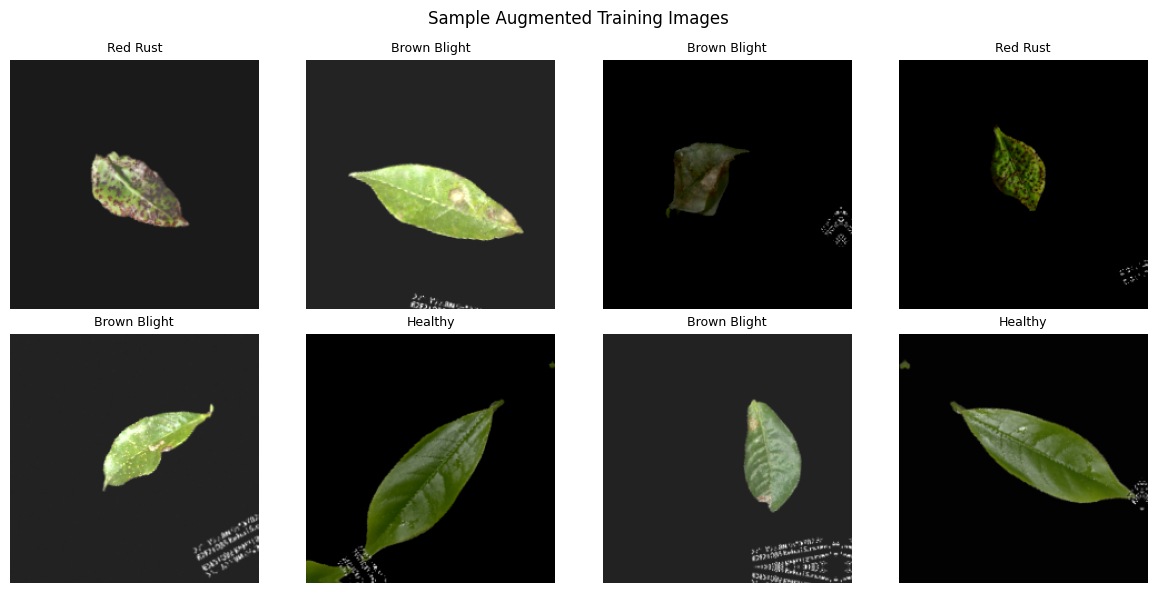

In [ ]:
def show_sample_batch(dataset, class_names, n=8):
    plt.figure(figsize=(12, 6))
    for images, lbls in dataset.take(1):
        for i in range(min(n, images.shape[0])):
            ax = plt.subplot(2, 4, i + 1)
            plt.imshow(images[i].numpy())
            raw_name = class_names[int(tf.argmax(lbls[i]))]
            plt.title(DISPLAY_NAME_MAP.get(raw_name, raw_name), fontsize=9)
            plt.axis("off")
    plt.suptitle("Sample Augmented Training Images")
    plt.tight_layout()
    plt.show()


show_sample_batch(train_ds, class_names)

## 5. MLflow Setup

Uses a local SQLite backend (`mlflow.db`), matching the fix applied in the
original TeaCare AI project after MLflow deprecated the plain-folder store.

In [ ]:
!pip install -q mlflow

import mlflow
import mlflow.keras

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(CFG.mlflow_experiment_name)

print("MLflow experiment set to:", CFG.mlflow_experiment_name)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

2026/07/07 09:21:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/07 09:21:46 INFO mlflow.store.db.utils: Updating database tables
2026/07/07 09:21:48 INFO mlflow.tracking.fluent: Experiment with name 'LeafScanAI_EfficientNetB0' does not exist. Creating a new experiment.


MLflow experiment set to: LeafScanAI_EfficientNetB0


## 6. Model — EfficientNetB0 Transfer Learning (Frozen Base)

Same proven architecture as TeaCare AI: frozen EfficientNetB0 base,
GlobalAveragePooling2D, Dropout, Dense head, Dropout, Softmax — now with
`num_classes=4`.

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0


def build_model(input_shape, num_classes, dropout_rate_1=0.3, dropout_rate_2=0.2,
                dense_units=128, learning_rate=1e-3):
    base_model = EfficientNetB0(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape, name="input_image")
    x = layers.Rescaling(255.0, name="restore_0_255_range")(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(dropout_rate_1, name="dropout_1")(x)
    x = layers.Dense(dense_units, activation="relu", name="dense_head")(x)
    x = layers.Dropout(dropout_rate_2, name="dropout_2")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="LeafScanAI_EfficientNetB0")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_model(input_shape=CFG.image_size + (3,), num_classes=NUM_CLASSES)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "LeafScanAI_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_0_255_range (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 7. Train with MLflow Tracking

In [ ]:
class MLflowMetricsLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        mlflow.log_metrics(
            {
                "train_accuracy": logs.get("accuracy"),
                "train_loss": logs.get("loss"),
                "val_accuracy": logs.get("val_accuracy"),
                "val_loss": logs.get("val_loss"),
            },
            step=epoch,
        )


EPOCHS = 30

with mlflow.start_run(run_name="leafscan_efficientnetb0_frozen_base") as run:
    print("Started MLflow run:", run.info.run_id)

    mlflow.log_params({
        "base_model": "EfficientNetB0",
        "base_model_trainable": False,
        "image_size": f"{CFG.image_size[0]}x{CFG.image_size[1]}",
        "batch_size": CFG.batch_size,
        "epochs_max": EPOCHS,
        "learning_rate": 1e-3,
        "optimizer": "Adam",
        "loss_function": "categorical_crossentropy",
        "train_size": len(train_paths),
        "val_size": len(val_paths),
        "test_size": len(test_paths),
        "num_classes": NUM_CLASSES,
        "dataset": "harjindersinghdibru/tealeafnet",
        "known_caveat_black_background": True,
        "known_caveat_preaugmented_duplicates_possible": True,
    })

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(filepath=CFG.model_output_path, monitor="val_loss", save_best_only=True, verbose=1),
        MLflowMetricsLogger(),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    print("\nTraining complete. Best model saved to:", CFG.model_output_path)

Started MLflow run: 47ca4e1de62e4239a1b12ddcb3f88782
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.6955 - loss: 0.7521
Epoch 1: val_loss improved from None to 0.38701, saving model to /content/models/leafscan_model.keras

Epoch 1: finished saving model to /content/models/leafscan_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 222s 606ms/step - accuracy: 0.8123 - loss: 0.5031 - val_accuracy: 0.8547 - val_loss: 0.3870 - learning_rate: 0.0010
Epoch 2/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9135 - loss: 0.2477
Epoch 2: val_loss improved from 0.38701 to 0.34539, saving model to /content/models/leafscan_model.keras

Epoch 2: finished saving model to /content/models/leafscan_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9186 - loss: 0.2370 - val_accuracy: 0.8667 - val_loss: 0.3454 - learning_rate: 0.0010
Epoch 3/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9359 - loss: 0.1746
Epoch 3: val_loss did not improve from 0.34539


## 8. Evaluation on the Held-Out Test Set

Accuracy, precision/recall/F1 (macro + weighted), confusion matrix, and
logging final results + artifacts to the same MLflow run.

Test Accuracy: 0.9360
Macro F1: 0.9363 | Weighted F1: 0.9362

                 precision    recall  f1-score   support

   Brown Blight       0.90      0.89      0.90       188
        Healthy       0.99      0.97      0.98       187
       Red Rust       1.00      0.89      0.94       188
Red Spider Mite       0.87      0.99      0.93       187

       accuracy                           0.94       750
      macro avg       0.94      0.94      0.94       750
   weighted avg       0.94      0.94      0.94       750



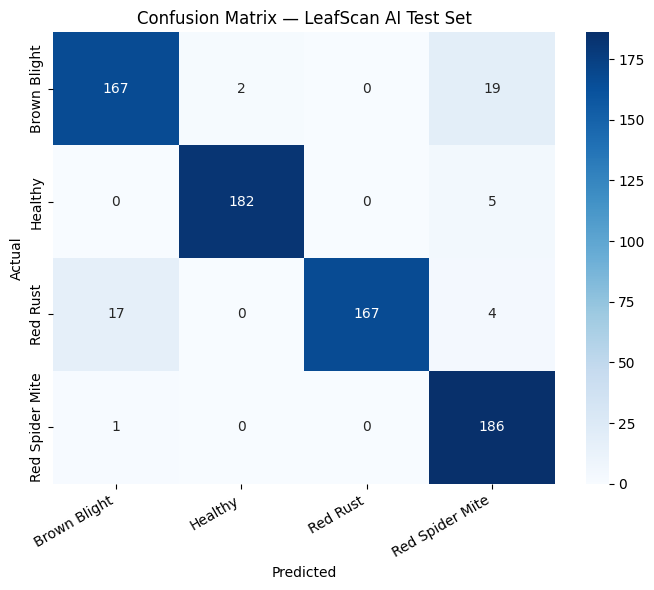

2026/07/07 09:29:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/07 09:29:33 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



All results logged to MLflow. Model ready at: /content/models/leafscan_model.keras

Remember: download this file from the Colab file browser before closing this session.


In [ ]:
best_model = tf.keras.models.load_model(CFG.model_output_path)

y_true, y_pred_probs = [], []
for images, one_hot_labels in test_ds:
    y_pred_probs.append(best_model.predict(images, verbose=0))
    y_true.append(one_hot_labels.numpy())

y_true = np.concatenate(y_true, axis=0)
y_pred_probs = np.concatenate(y_pred_probs, axis=0)
y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true_labels, y_pred_labels, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true_labels, y_pred_labels, average="weighted", zero_division=0
)

display_names = [DISPLAY_NAME_MAP.get(c, c) for c in class_names]

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f}")
print("\n" + classification_report(y_true_labels, y_pred_labels, target_names=display_names, zero_division=0))

report_dict = classification_report(
    y_true_labels, y_pred_labels, target_names=display_names, zero_division=0, output_dict=True
)

with mlflow.start_run(run_id=run.info.run_id):
    mlflow.log_metrics({
        "test_accuracy": float(test_accuracy),
        "test_precision_macro": float(precision_macro),
        "test_recall_macro": float(recall_macro),
        "test_f1_macro": float(f1_macro),
        "test_precision_weighted": float(precision_weighted),
        "test_recall_weighted": float(recall_weighted),
        "test_f1_weighted": float(f1_weighted),
    })

    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=range(NUM_CLASSES))
    fig_cm = plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=display_names, yticklabels=display_names)
    plt.title("Confusion Matrix — LeafScan AI Test Set")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    cm_path = f"{CFG.plots_dir}/confusion_matrix.png"
    fig_cm.savefig(cm_path)
    plt.show()
    mlflow.log_artifact(cm_path)

    report_path = f"{CFG.plots_dir}/classification_report.json"
    with open(report_path, "w") as f:
        json.dump(report_dict, f, indent=2)
    mlflow.log_artifact(report_path)

    mlflow.keras.log_model(best_model, artifact_path="model")
    mlflow.log_artifact(CFG.model_output_path)

print("\nAll results logged to MLflow. Model ready at:", CFG.model_output_path)
print("\nRemember: download this file from the Colab file browser before closing this session.")

## 9. Reminder — Known Caveats for Your Report

Whatever accuracy this model achieves, document these two points honestly
alongside it:

1. **Artificial black backgrounds**: this model may not generalize well to
   real-world photos with natural backgrounds, since it was trained
   exclusively on background-removed images.
2. **Possible train/test leakage from pre-applied augmentation**: the
   dataset was already balanced to 1,250 images/class by the original
   author using augmentation before we ever split it. Near-duplicate images
   may exist across our train/val/test splits, which can make test accuracy
   look better than true real-world generalization would be.

In [ ]:
import os
print(os.path.exists("/content/data"))

False
